# Mini-Project 1 — Advanced Python Data Exploration & Automated Reporting

**Dataset:** Sample - Superstore 2019  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

This notebook follows a simple end-to-end analytics workflow: load the data, inspect it, clean it, create useful features, explore the data, visualize the main patterns, calculate KPIs, and export the results automatically.

## 1. Imports and project setup

Pandas is used for data handling, NumPy for numerical work, and Matplotlib/Seaborn for charts. Logging is included so processing errors can be recorded.

In [1]:
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

logging.basicConfig(
    filename="superstore_project.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
sns.set_theme(style="whitegrid")

# Keep the notebook portable: input/output paths are relative to the delivery folder.
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "superstore_output"
OUTPUT_DIR.mkdir(exist_ok=True)

FILE_PATH = BASE_DIR / "Sample - Superstore 2019.xlsx"
FALLBACK_XLS = BASE_DIR / "Sample - Superstore 2019.xls"
print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /mnt/data/superstore_project/superstore_output


## 2. Load the workbook

The workbook has `Orders`, `People`, and `Returns` sheets. The Orders sheet is the main analytical table. The Returns sheet is used later for a return-rate KPI.

In [2]:
def load_superstore(file_path, fallback_path=None):
    try:
        orders = pd.read_excel(file_path, sheet_name="Orders")
        people = pd.read_excel(file_path, sheet_name="People")
        returns = pd.read_excel(file_path, sheet_name="Returns")
        logging.info("Workbook loaded successfully.")
        return orders, people, returns
    except FileNotFoundError as exc:
        logging.exception("Input file not found.")
        raise FileNotFoundError(f"Could not find {file_path}") from exc
    except ImportError:
        if fallback_path is not None and fallback_path.exists():
            logging.warning("XLS reader unavailable. Using XLSX fallback.")
            return (
                pd.read_excel(fallback_path, sheet_name="Orders"),
                pd.read_excel(fallback_path, sheet_name="People"),
                pd.read_excel(fallback_path, sheet_name="Returns")
            )
        raise
    except ValueError as exc:
        logging.exception("Expected workbook sheet was not found.")
        raise ValueError("Could not read the expected workbook sheets.") from exc

orders_raw, people, returns = load_superstore(FILE_PATH, FALLBACK_XLS)

print("Orders:", orders_raw.shape)
print("People:", people.shape)
print("Returns:", returns.shape)
display(orders_raw.head())

Orders: (9994, 21)
People: (4, 2)
Returns: (800, 2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Inspect structure and metadata

The first inspection checks columns, data types, summary statistics, missing values, and duplicate records.

In [3]:
print("Columns:")
print(orders_raw.columns.tolist())

print("\nData types:")
display(orders_raw.dtypes.to_frame("dtype"))

print("\nSummary statistics:")
display(orders_raw.describe(include="all").T)

print("\nMissing values:")
display(orders_raw.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", orders_raw.duplicated().sum())
orders_raw.info()

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:


,dtype
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object



Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2019-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2018-04-30 10:03:51.979187712,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2018-05-04 09:03:29.645787392,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,missing
Postal Code,11
Order ID,0
Order Date,0
Ship Date,0
Row ID,0
Ship Mode,0
Customer ID,0
Segment,0
Customer Name,0
Country/Region,0



Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   objec

## 4. Reusable preprocessing class

The course material presents reusable functions and OOP as useful ways to organize analytics pipelines. This class keeps the cleaning steps together and makes them reusable.

In [4]:
class SuperstorePreprocessor:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.original_rows = len(self.df)
        self.log = {}

    def clean_text(self):
        for col in self.df.select_dtypes(include="object").columns:
            self.df[col] = self.df[col].astype("string").str.strip()
        self.log["text_columns_cleaned"] = len(
            self.df.select_dtypes(include="object").columns
        )
        return self

    def convert_dates(self):
        for col in ["Order Date", "Ship Date"]:
            self.df[col] = pd.to_datetime(self.df[col], errors="coerce")
        self.log["invalid_date_cells"] = int(
            self.df[["Order Date", "Ship Date"]].isna().sum().sum()
        )
        return self

    def handle_missing(self):
        if self.df["Postal Code"].isna().any():
            self.df["Postal Code"] = self.df["Postal Code"].fillna(
                self.df["Postal Code"].mode().iloc[0]
            )
        for col in self.df.select_dtypes(include=np.number).columns:
            if self.df[col].isna().any():
                self.df[col] = self.df[col].fillna(self.df[col].median())
        self.log["missing_cells_after_cleaning"] = int(self.df.isna().sum().sum())
        return self

    def remove_duplicates(self):
        before = len(self.df)
        self.df = self.df.drop_duplicates().copy()
        self.log["duplicates_removed"] = before - len(self.df)
        return self

    def validate(self):
        self.log["non_positive_sales"] = int((self.df["Sales"] <= 0).sum())
        self.log["non_positive_quantity"] = int((self.df["Quantity"] <= 0).sum())
        return self

    def cap_outliers(self, columns):
        counts = {}
        for col in columns:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            counts[col] = int(((self.df[col] < lower) | (self.df[col] > upper)).sum())
            # Keep the original business values and store a capped version for analysis.
            self.df[f"{col} Capped"] = self.df[col].clip(lower, upper)
        self.log["outliers_detected_before_capping"] = counts
        return self

    def get_data(self):
        return self.df

numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]

pre = (
    SuperstorePreprocessor(orders_raw)
    .clean_text()
    .convert_dates()
    .handle_missing()
    .remove_duplicates()
    .validate()
)

orders_clean = pre.get_data()

print("Rows before cleaning:", pre.original_rows)
print("Rows after duplicate removal:", len(orders_clean))
display(pd.DataFrame(pre.log, index=[0]))

Rows before cleaning: 9994
Rows after duplicate removal: 9994


,text_columns_cleaned,invalid_date_cells,missing_cells_after_cleaning,duplicates_removed,non_positive_sales,non_positive_quantity
0,0,0,0,0,0,0


## 5. Outlier detection

Box plots are used to identify unusually high or low values. The course material notes that an outlier may be an error or a legitimate rare case, so I use capping instead of deleting transactions.

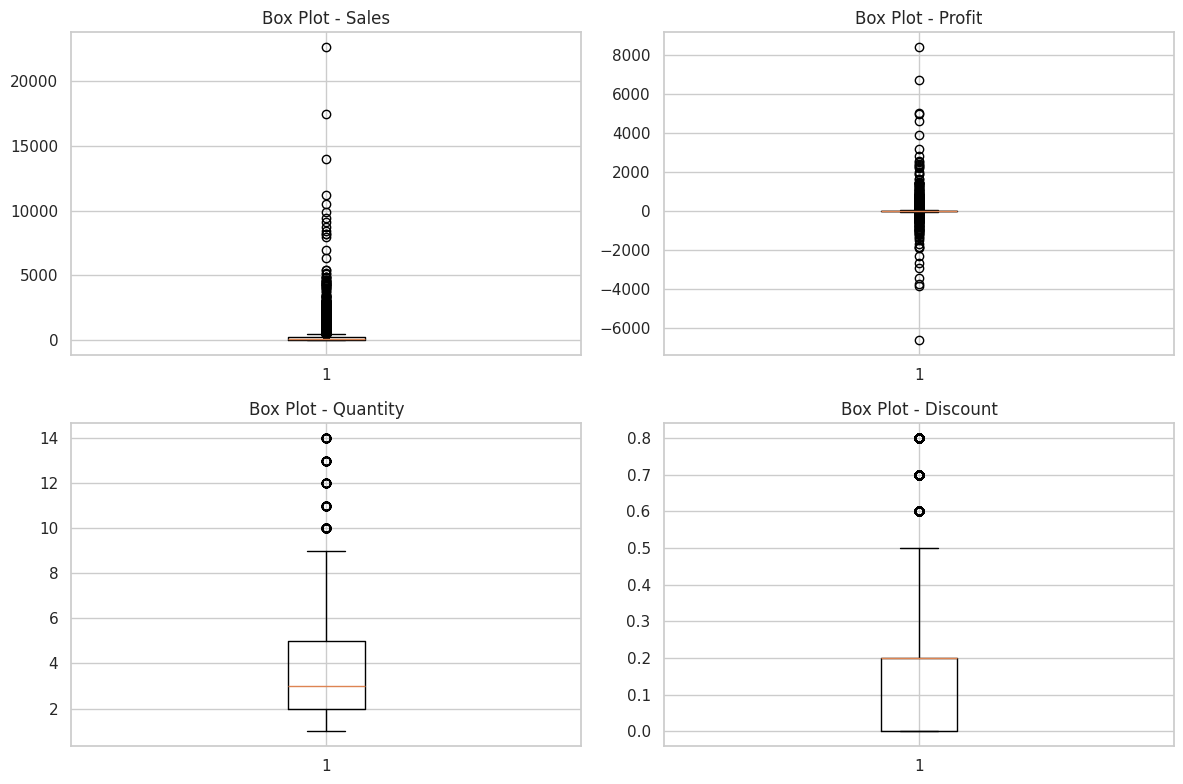

,outliers_detected_before_capping
0,NaN


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.boxplot(orders_clean[col].dropna(), vert=True)
    ax.set_title(f"Box Plot - {col}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

pre2 = SuperstorePreprocessor(orders_clean).cap_outliers(numeric_cols)
orders_clean = pre2.get_data()
display(pd.DataFrame(pre2.log, index=[0]))

## 6. Feature engineering

The required features are Profit Margin, Shipping Duration, and Sales Performance Category. Year and month fields are also added for trend analysis. Feature engineering is the process of creating or transforming variables so raw data becomes more useful for analysis.

In [6]:
def add_features(dataframe):
    df = dataframe.copy()

    df["Profit Margin"] = np.where(
        df["Sales"] != 0,
        (df["Profit"] / df["Sales"]) * 100,
        0
    )

    df["Shipping Duration"] = (
        df["Ship Date"] - df["Order Date"]
    ).dt.days

    df["Sales Performance Category"] = np.select(
        [
            df["Profit Margin"] < 0,
            df["Profit Margin"] < 10,
            df["Profit Margin"] < 20
        ],
        ["Loss", "Low", "Medium"],
        default="High"
    )

    df["Order Year"] = df["Order Date"].dt.year
    df["Order Month"] = df["Order Date"].dt.month
    df["Order Month Name"] = df["Order Date"].dt.strftime("%b")

    return df

orders = add_features(orders_clean)

display(orders[
    ["Sales", "Profit", "Profit Margin",
     "Shipping Duration", "Sales Performance Category"]
].head())

,Sales,Profit,Profit Margin,Shipping Duration,Sales Performance Category
0,261.9600,41.9136,16.00,3,Medium
1,731.9400,219.5820,30.00,3,High
2,14.6200,6.8714,47.00,4,High
3,957.5775,-383.0310,-40.00,7,Loss
4,22.3680,2.5164,11.25,7,Medium


## 7. Optimize memory usage

Repeated text values are converted to categorical data and numeric values are downcast where possible.

In [7]:
def optimize_memory(dataframe):
    df = dataframe.copy()

    category_columns = [
        "Ship Mode", "Segment", "Country/Region", "City", "State",
        "Region", "Category", "Sub-Category", "Sales Performance Category"
    ]
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype("category")

    for col in ["Row ID", "Quantity", "Shipping Duration", "Order Year", "Order Month"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in ["Postal Code", "Sales", "Discount", "Profit", "Profit Margin"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], downcast="float")

    return df

before_mb = orders.memory_usage(deep=True).sum() / 1024**2
orders = optimize_memory(orders)
after_mb = orders.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before: {before_mb:.2f} MB")
print(f"Memory after:  {after_mb:.2f} MB")
print(f"Reduction: {(1-after_mb/before_mb)*100:.1f}%")

Memory before: 9.80 MB
Memory after:  4.58 MB
Reduction: 53.3%


## 8. KPI summary

The KPIs cover sales, profitability, customers, orders, quantity, average order value, and returns.

In [8]:
def build_kpis(orders_df, returns_df):
    sales = orders_df["Sales"].sum()
    profit = orders_df["Profit"].sum()
    order_count = orders_df["Order ID"].nunique()
    customer_count = orders_df["Customer ID"].nunique()

    returned_orders = returns_df.loc[
        returns_df["Returned"].astype("string").str.strip().str.lower().eq("yes"),
        "Order ID"
    ].nunique()

    return pd.DataFrame({
        "KPI": [
            "Total Sales", "Total Profit", "Overall Profit Margin (%)",
            "Total Orders", "Unique Customers", "Total Quantity",
            "Average Order Value", "Returned Orders", "Return Rate (%)"
        ],
        "Value": [
            sales,
            profit,
            profit / sales * 100,
            order_count,
            customer_count,
            orders_df["Quantity"].sum(),
            sales / order_count,
            returned_orders,
            returned_orders / order_count * 100
        ]
    })

kpis = build_kpis(orders, returns)
display(kpis)

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Overall Profit Margin (%),1.246722e+01
3,Total Orders,5.009000e+03
4,Unique Customers,7.930000e+02
5,Total Quantity,3.787300e+04
6,Average Order Value,4.586147e+02
7,Returned Orders,2.960000e+02
8,Return Rate (%),5.909363e+00


## 9. EDA summaries

Grouping and aggregation are used to compare categories and regions, and to understand sales and profit together.

In [9]:
category_summary = (
    orders.groupby("Category", observed=True)
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .sort_values("Sales", ascending=False)
)

region_summary = (
    orders.groupby("Region", observed=True)
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .sort_values("Sales", ascending=False)
)

print("Category summary")
display(category_summary)

print("Region summary")
display(region_summary)

print("Performance categories")
display(orders["Sales Performance Category"].value_counts().to_frame("Count"))

Category summary


,Sales,Profit
Category,,
Technology,836154.0330,145454.953125
Furniture,741999.7953,18451.273438
Office Supplies,719047.0320,122490.804688


Region summary


,Sales,Profit
Region,,
West,725457.8245,108418.445312
East,678781.2400,91522.781250
Central,501239.8908,39706.363281
South,391721.9050,46749.429688


Performance categories


,Count
Sales Performance Category,
High,5962
Loss,1871
Medium,1096
Low,1065


## 10. Visualization — Sales by Category

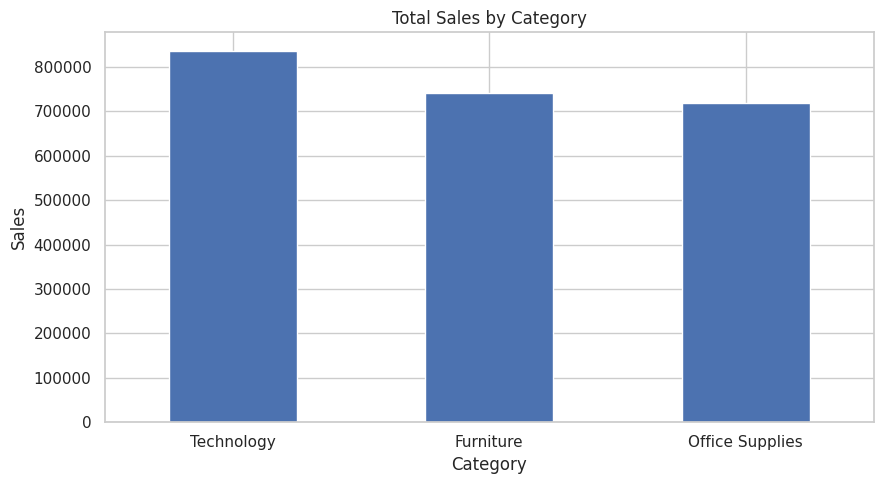

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
category_summary["Sales"].plot(kind="bar", ax=ax)
ax.set_title("Total Sales by Category")
ax.set_xlabel("Category"); ax.set_ylabel("Sales")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"02_sales_by_category.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Visualization — Profit by Region

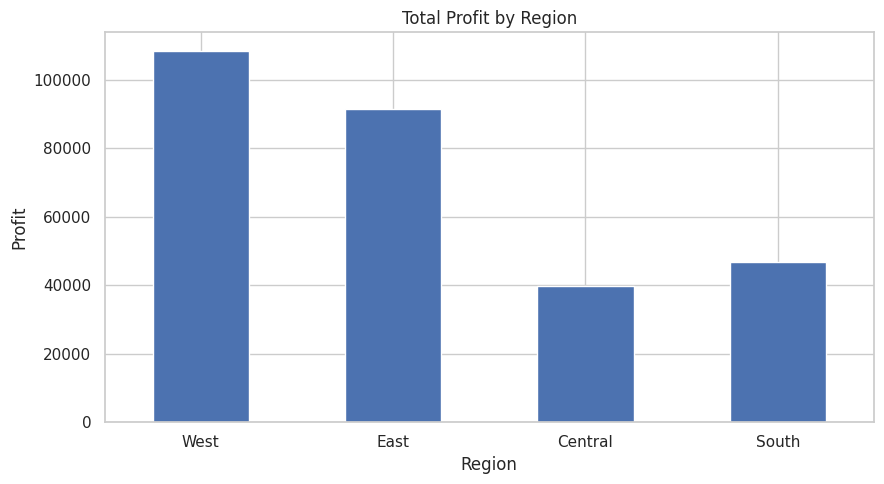

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
region_summary["Profit"].plot(kind="bar", ax=ax)
ax.set_title("Total Profit by Region")
ax.set_xlabel("Region"); ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"03_profit_by_region.png", dpi=150, bbox_inches="tight"); plt.show()

## 12. Visualization — Sales distribution

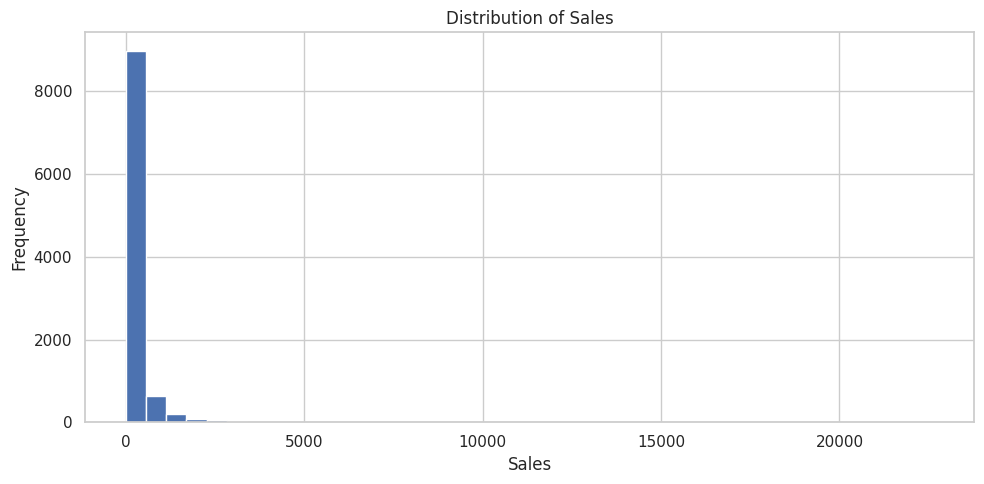

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(orders["Sales"], bins=40)
ax.set_title("Distribution of Sales"); ax.set_xlabel("Sales"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"04_sales_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

## 13. Visualization — Profit distribution

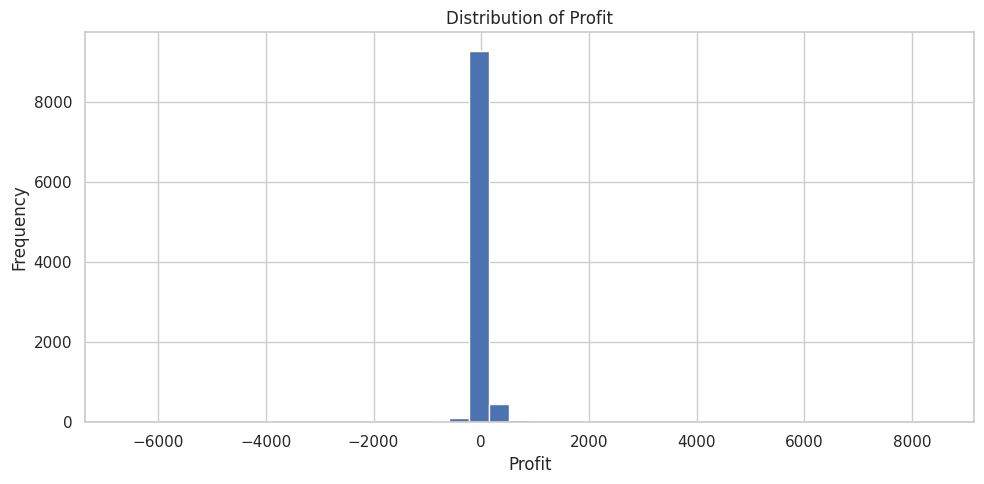

In [13]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(orders["Profit"], bins=40)
ax.set_title("Distribution of Profit"); ax.set_xlabel("Profit"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"05_profit_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

## 14. Visualization — Sales vs Profit

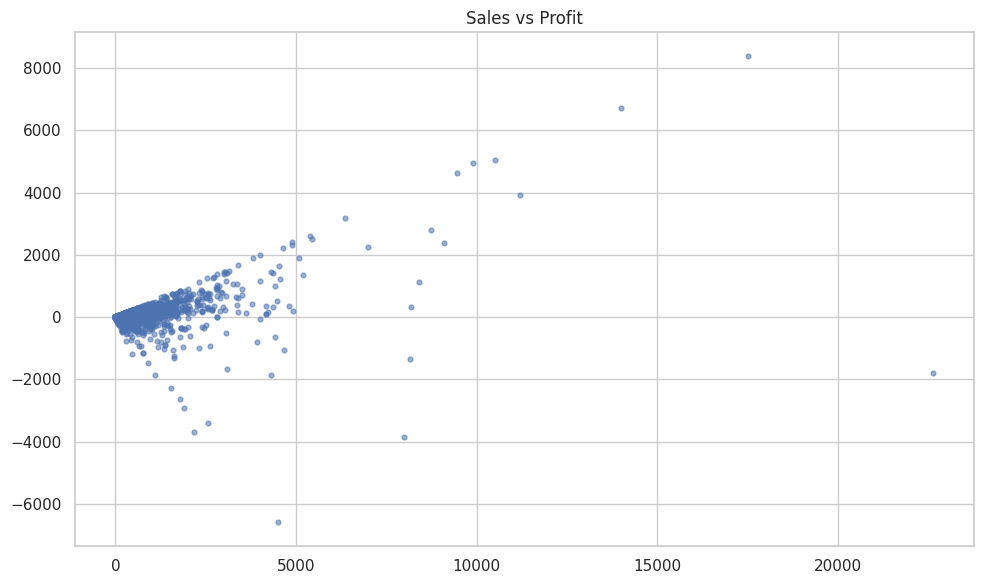

In [14]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(orders["Sales"], orders["Profit"], alpha=.55, s=12)
ax.set_title("Sales vs Profit")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"06_sales_vs_profit.png", dpi=150, bbox_inches="tight"); plt.show()

## 15. Correlation analysis

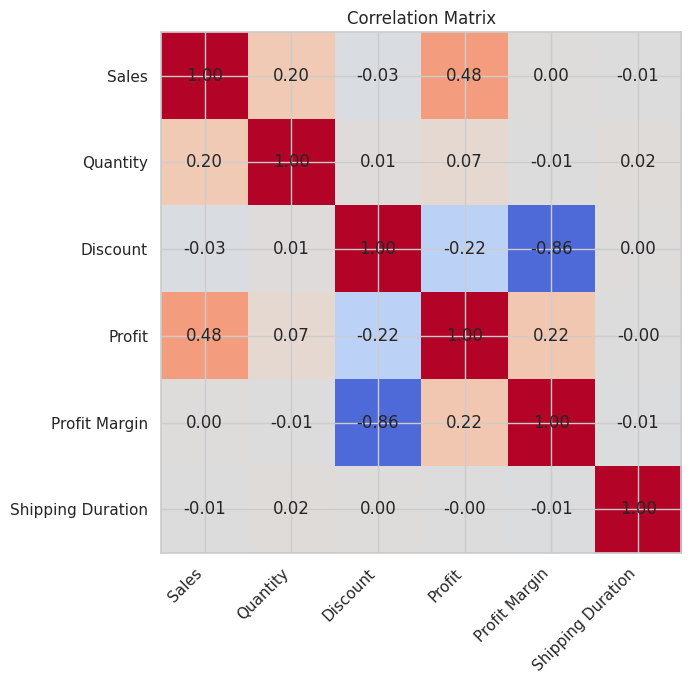

Sales / Profit correlation: 0.479


In [15]:
corr_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Shipping Duration"]
corr_matrix = orders[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns))); ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index))); ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center")
ax.set_title("Correlation Matrix")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"07_correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

print("Sales / Profit correlation:", round(corr_matrix.loc["Sales","Profit"], 3))

## 16. Visualization — Monthly sales trend

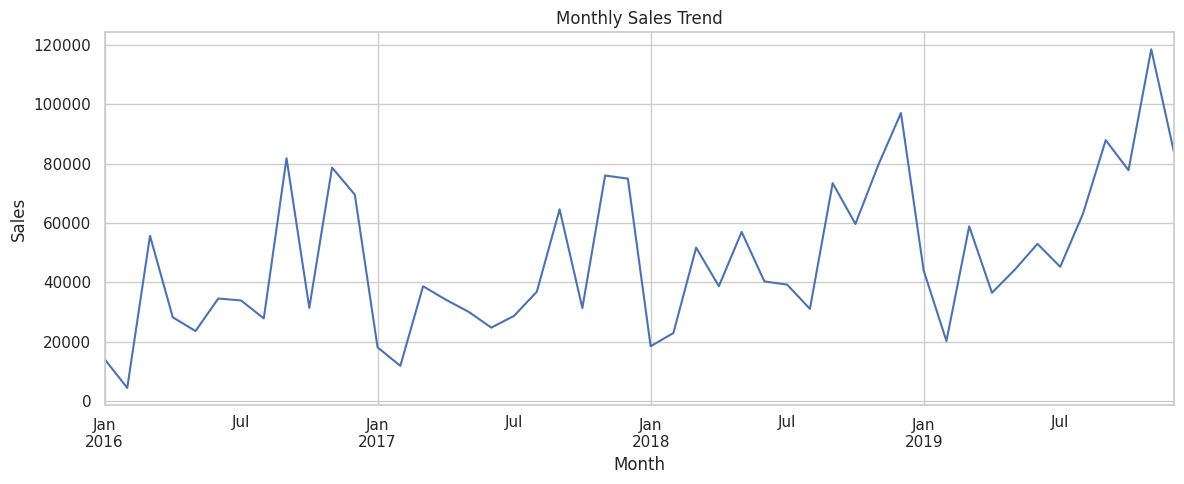

In [16]:
monthly_sales = orders.set_index("Order Date").resample("MS")["Sales"].sum()
fig, ax = plt.subplots(figsize=(12,5))
monthly_sales.plot(ax=ax)
ax.set_title("Monthly Sales Trend"); ax.set_xlabel("Month"); ax.set_ylabel("Sales")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"08_monthly_sales_trend.png", dpi=150, bbox_inches="tight"); plt.show()

## 17. Visualization — Profit margin by category

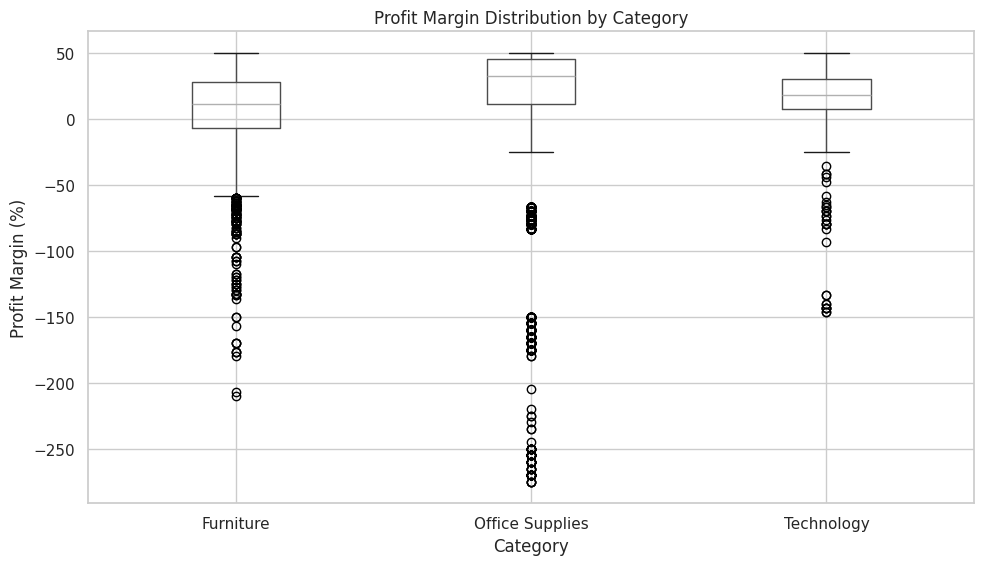

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
orders.boxplot(column="Profit Margin", by="Category", ax=ax)
fig.suptitle("")
ax.set_title("Profit Margin Distribution by Category")
ax.set_xlabel("Category"); ax.set_ylabel("Profit Margin (%)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"09_profit_margin_by_category.png", dpi=150, bbox_inches="tight"); plt.show()

## 18. Visualization — Shipping duration by ship mode

,mean,median,count
Ship Mode,,,
First Class,2.182705,2.0,1538
Same Day,0.044199,0.0,543
Second Class,3.237532,3.0,1945
Standard Class,5.006535,5.0,5968


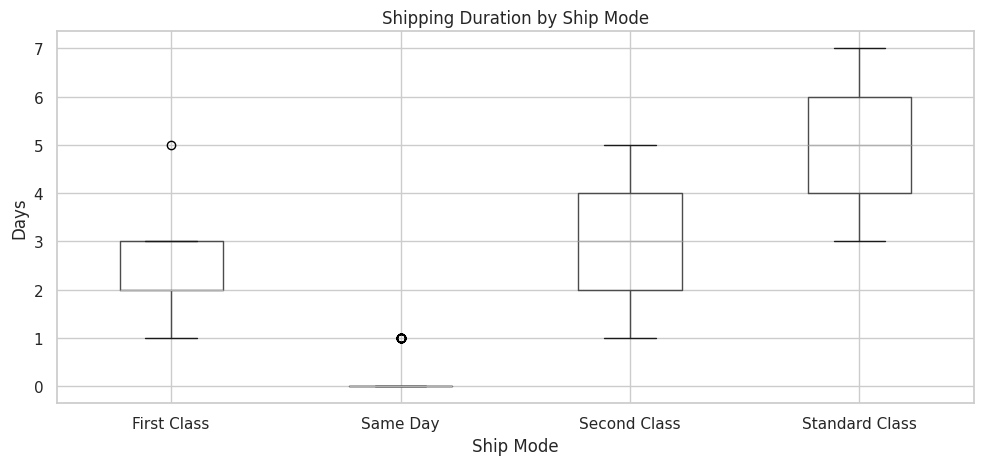

In [18]:
shipping_summary = orders.groupby("Ship Mode", observed=True)["Shipping Duration"].agg(["mean","median","count"])
display(shipping_summary)

fig, ax = plt.subplots(figsize=(10,5))
orders.boxplot(column="Shipping Duration", by="Ship Mode", ax=ax)
fig.suptitle("")
ax.set_title("Shipping Duration by Ship Mode")
ax.set_xlabel("Ship Mode"); ax.set_ylabel("Days")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"10_shipping_duration_by_mode.png", dpi=150, bbox_inches="tight"); plt.show()

## 19. Statistical analysis

Descriptive statistics and grouped statistics are used to compare distributions and performance. The correlation matrix is also exported as part of the automated report.

In [19]:
descriptive_stats = orders[corr_cols].describe().T
category_stats = orders.groupby("Category", observed=True).agg(
    Avg_Sales=("Sales","mean"),
    Avg_Profit=("Profit","mean"),
    Avg_Profit_Margin=("Profit Margin","mean"),
    Avg_Shipping_Days=("Shipping Duration","mean")
).sort_values("Avg_Profit_Margin", ascending=False)

region_stats = orders.groupby("Region", observed=True).agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Avg_Profit_Margin=("Profit Margin","mean")
).sort_values("Profit", ascending=False)

display(descriptive_stats)
display(category_stats)
display(region_stats)

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444000,17.28000,54.4900,209.940,22638.480000
Quantity,9994.0,3.789574,2.225110,1.000000,2.00000,3.0000,5.000,14.000000
Discount,9994.0,0.156203,0.206452,0.000000,0.00000,0.2000,0.200,0.800000
Profit,9994.0,28.656897,234.260101,-6599.978027,1.72875,8.6665,29.364,8399.975586
Profit Margin,9994.0,12.031392,46.675434,-275.000000,7.50000,27.0000,36.250,50.000000
Shipping Duration,9994.0,3.958075,1.747937,0.000000,3.00000,4.0000,5.000,7.000000


,Avg_Sales,Avg_Profit,Avg_Profit_Margin,Avg_Shipping_Days
Category,,,,
Technology,452.709276,78.752007,15.613806,3.923119
Office Supplies,119.324101,20.327051,13.803029,3.983405
Furniture,349.834887,8.699327,3.878353,3.916549


,Sales,Profit,Avg_Profit_Margin
Region,,,
West,725457.8245,108418.445312,21.948662
East,678781.2400,91522.781250,16.722696
South,391721.9050,46749.429688,16.351904
Central,501239.8908,39706.363281,-10.407294


## 20. Customer and product analysis

Customer and product summaries add a simple customer-behavior and product-performance view.

In [20]:
customer_summary = orders.groupby(["Customer ID","Customer Name"], observed=True).agg(
    Sales=("Sales","sum"), Profit=("Profit","sum"),
    Orders=("Order ID","nunique"), Quantity=("Quantity","sum")
).sort_values("Sales", ascending=False)

product_summary = orders.groupby("Product Name", observed=True).agg(
    Sales=("Sales","sum"), Profit=("Profit","sum"), Quantity=("Quantity","sum")
).sort_values("Sales", ascending=False)

print("Top customers:")
display(customer_summary.head(10))
print("Top products:")
display(product_summary.head(10))

Top customers:


,,Sales,Profit,Orders,Quantity
Customer ID,Customer Name,,,,
SM-20320,Sean Miller,25043.050,-1980.739258,5,50
TC-20980,Tamara Chand,19052.218,8981.323242,5,42
RB-19360,Raymond Buch,15117.339,6976.096191,6,71
TA-21385,Tom Ashbrook,14595.620,4703.788086,4,36
AB-10105,Adrian Barton,14473.571,5444.805176,10,73
KL-16645,Ken Lonsdale,14175.229,806.854980,12,113
SC-20095,Sanjit Chand,14142.334,5757.411621,9,87
HL-15040,Hunter Lopez,12873.298,5622.429199,6,50
SE-20110,Sanjit Engle,12209.438,2650.676758,11,78


Top products:


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.927734,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.039062,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.078369,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,0.000000,39
GBC DocuBind TL300 Electric Binding System,19823.479,2233.505127,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,760.980469,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.883301,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.976562,12
GBC DocuBind P400 Electric Binding System,17965.068,-1878.166260,27


## 21. Automated analytical report

The report text is generated from calculated values instead of manually typing the results, so it can be reused when the dataset changes.

In [21]:
def generate_summary(orders_df, kpi_df, category_df, region_df):
    total_sales = kpi_df.loc[kpi_df["KPI"].eq("Total Sales"),"Value"].iloc[0]
    total_profit = kpi_df.loc[kpi_df["KPI"].eq("Total Profit"),"Value"].iloc[0]
    margin = kpi_df.loc[kpi_df["KPI"].eq("Overall Profit Margin (%)"),"Value"].iloc[0]
    best_category = category_df["Sales"].idxmax()
    best_region = region_df["Profit"].idxmax()
    avg_ship = orders_df["Shipping Duration"].mean()
    loss_orders = int(orders_df["Sales Performance Category"].eq("Loss").sum())

    return "\n".join([
        "SUPERSTORE AUTOMATED ANALYTICAL SUMMARY",
        "="*45,
        f"Total sales: {total_sales:,.2f}",
        f"Total profit: {total_profit:,.2f}",
        f"Overall profit margin: {margin:.2f}%",
        f"Top category by sales: {best_category}",
        f"Top region by profit: {best_region}",
        f"Average shipping duration: {avg_ship:.2f} days",
        f"Orders classified as Loss: {loss_orders:,}",
        "",
        "Main observations:",
        f"- {best_category} generated the highest total sales.",
        f"- {best_region} generated the highest total profit.",
        "- Sales and profit were reviewed together because high sales do not automatically mean high profitability.",
        "- Shipping duration was compared across ship modes."
    ])

summary_text = generate_summary(orders, kpis, category_summary, region_summary)
print(summary_text)

SUPERSTORE AUTOMATED ANALYTICAL SUMMARY
Total sales: 2,297,200.86
Total profit: 286,397.03
Overall profit margin: 12.47%
Top category by sales: Technology
Top region by profit: West
Average shipping duration: 3.96 days
Orders classified as Loss: 1,871

Main observations:
- Technology generated the highest total sales.
- West generated the highest total profit.
- Sales and profit were reviewed together because high sales do not automatically mean high profitability.
- Shipping duration was compared across ship modes.


## 22. Export all results automatically

The final folder contains the cleaned dataset, KPI summary, statistical summaries, correlation matrix, top customer/product tables, text report, HTML report, and all visualizations.

In [22]:
orders.to_csv(OUTPUT_DIR/"superstore_cleaned.csv", index=False)
kpis.to_csv(OUTPUT_DIR/"kpi_summary.csv", index=False)
corr_matrix.to_csv(OUTPUT_DIR/"correlation_matrix.csv")
category_summary.to_csv(OUTPUT_DIR/"category_summary.csv")
region_summary.to_csv(OUTPUT_DIR/"region_summary.csv")
customer_summary.head(100).to_csv(OUTPUT_DIR/"top_100_customers.csv")
product_summary.head(100).to_csv(OUTPUT_DIR/"top_100_products.csv")

with open(OUTPUT_DIR/"automated_summary.txt","w",encoding="utf-8") as f:
    f.write(summary_text)

html = (
    "<html><head><meta charset='utf-8'><title>Superstore Report</title></head><body>"
    "<h1>Superstore Automated Analytical Report</h1>"
    "<h2>KPI Summary</h2>" + kpis.to_html(index=False) +
    "<h2>Category Summary</h2>" + category_summary.to_html() +
    "<h2>Region Summary</h2>" + region_summary.to_html() +
    "<h2>Correlation Matrix</h2>" + corr_matrix.to_html() +
    "<h2>Summary</h2><pre>" + summary_text + "</pre>"
    "</body></html>"
)
with open(OUTPUT_DIR/"superstore_report.html","w",encoding="utf-8") as f:
    f.write(html)

print("Export completed.")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(p.name)

Export completed.
01_outlier_boxplots.png
02_sales_by_category.png
03_profit_by_region.png
04_sales_distribution.png
05_profit_distribution.png
06_sales_vs_profit.png
07_correlation_heatmap.png
08_monthly_sales_trend.png
09_profit_margin_by_category.png
10_shipping_duration_by_mode.png
automated_summary.txt
category_summary.csv
correlation_matrix.csv
kpi_summary.csv
region_summary.csv
superstore_cleaned.csv
superstore_report.html
top_100_customers.csv
top_100_products.csv


## 23. Final checks

These checks confirm that the final dataset contains the engineered features, has no missing cells after preprocessing, and that at least eight visualizations were saved.

In [23]:
assert orders.shape[0] > 0
assert orders["Profit Margin"].notna().all()
assert orders["Shipping Duration"].notna().all()
assert orders["Sales Performance Category"].notna().all()
assert orders.isna().sum().sum() == 0
assert orders.duplicated().sum() == 0

plot_files = list(OUTPUT_DIR.glob("*.png"))
print("Final dataset shape:", orders.shape)
print("Visualizations saved:", len(plot_files))
print("Missing cells:", int(orders.isna().sum().sum()))
print("Duplicate rows:", int(orders.duplicated().sum()))
print("Project completed successfully.")

Final dataset shape: (9994, 31)
Visualizations saved: 10
Missing cells: 0
Duplicate rows: 0
Project completed successfully.
